In [1]:
#Manipulacao dos dados
import numpy as np
import pandas as pd

#divisao dos dados
from sklearn.model_selection import train_test_split, KFold, LeaveOneOut, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay, confusion_matrix, RocCurveDisplay #avaliacao
import matplotlib.pyplot as plt #visualizacao
from sklearn.tree import DecisionTreeClassifier #algoritmo de classificacao

import warnings
warnings.filterwarnings('ignore')

In [2]:
#https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic
dataset = pd.read_csv('Datasets/breast_cancer_wisconsin_diagnostic.csv')
dataset

,diagnosis,radius_Mean,texture_Mean,periMeter_Mean,area_Mean,sMoothness_Mean,coMpactness_Mean,concavity_Mean,concave points_Mean,syMMetry_Mean,...,radius_worst,texture_worst,periMeter_worst,area_worst,sMoothness_worst,coMpactness_worst,concavity_worst,concave points_worst,syMMetry_worst,fractal_diMension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [3]:
print(f"Tamanho do dataset: {dataset.shape}\n")
dataset.head()

Tamanho do dataset: (569, 31)



,diagnosis,radius_Mean,texture_Mean,periMeter_Mean,area_Mean,sMoothness_Mean,coMpactness_Mean,concavity_Mean,concave points_Mean,syMMetry_Mean,...,radius_worst,texture_worst,periMeter_worst,area_worst,sMoothness_worst,coMpactness_worst,concavity_worst,concave points_worst,syMMetry_worst,fractal_diMension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
X = dataset.drop(columns=["diagnosis"]) #Diagnosis -> Target
y = dataset["diagnosis"]

#Separando o conjunto de dados em treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) # Random_state: Usar um valor inteiro produzirá os mesmos resultados em diferentes chamadas.

In [19]:
model = DecisionTreeClassifier(random_state=199)
#treinando o modelo
model.fit(X_train, y_train)

#predição
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           B       0.91      0.93      0.92       107
           M       0.89      0.84      0.86        64

    accuracy                           0.90       171
   macro avg       0.90      0.89      0.89       171
weighted avg       0.90      0.90      0.90       171




#### Matriz de confusão
##### a função confusion matrix retorna uma matriz com a contagem de como cada  uma das classes está sendo classificada corretamente ou erroneamente

In [20]:
confusion_matrix(y_test, y_pred)


array([[100,   7],
       [ 10,  54]])

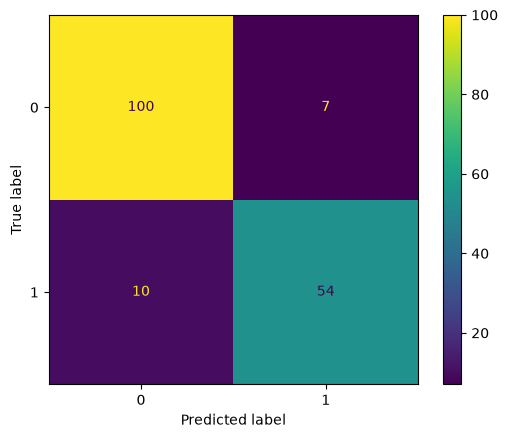

In [21]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

#### KFOLD
##### https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html
##### Fornece índices de treinamento/teste para dividir dados em conjuntos de treinamento/teste. Divide o conjunto de dados em k folds consecutivos (sem embaralhar "shuffle" por padrão)

In [22]:
def evaluate_model(kf):
    accuracies_list = []
    fold = 0
    for train, test in kf.split(X, y):
        
        X_train, X_test = X.iloc[train], X.iloc[test]
        y_train, y_test = y.iloc[train], y.iloc[test]

        model = DecisionTreeClassifier(random_state=199)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        print("Fold %d: %.3f" %(fold, accuracy_score(y_test, y_pred)))
        
        accuracies_list.append(accuracy_score(y_test, y_pred))
        fold += 1

    accuracies = np.array(accuracies_list)
    print("\nAcurácia média (desvio): %.3f +- (%.3f)" %(accuracies.mean(), accuracies.std()))

evaluate_model(KFold(n_splits=5, random_state=42, shuffle=True))
     

Fold 0: 0.947
Fold 1: 0.930
Fold 2: 0.895
Fold 3: 0.947
Fold 4: 0.947

Acurácia média (desvio): 0.933 +- (0.020)


# Otimização de Parâmetros

![Comparison of grid search and random search for hyperparameter optimization.](https://miro.medium.com/v2/resize:fit:1100/format:webp/0*yDmmJmvRowl0cSN8.png)

A Busca em Grade apresenta nove combinações de hiperparâmetros igualmente espaçadas, enquanto a Busca Aleatória apresenta combinações distribuídas aleatoriamente. Os gráficos superiores mostram o desempenho do modelo em função de um hiperparâmetro importante, enquanto os gráficos laterais mostram o desempenho em função de um hiperparâmetro pouco relevante.

#### GRID SEARCH CV
##### https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
##### O Grid-search é usado para encontrar os hiperparâmetros ideais de um modelo que resultem em previsões mais "precisas".

In [26]:
def grid_Search(skf):
  accuracies_list = []
  fold = 0

  for train, test in skf.split(X, y):
        X_train, X_test = X.iloc[train], X.iloc[test]
        y_train, y_test = y.iloc[train], y.iloc[test]

        model = DecisionTreeClassifier(random_state=199)
        parameters = {'min_samples_split': [10, 30],
                        'max_depth':[5, 30],
                        'max_features':[10, 30]
                        }
    
        grid = GridSearchCV(estimator = model,             # É o DecisionTree
                    param_grid = parameters,           # É aquele dicionário com valores para serem testados.
                    scoring = 'accuracy',              # A métrica de avaliação
                    cv = 5)
        
        grid.fit(X_train, y_train)

        y_pred = grid.predict(X_test)
    
        print("Melhor parametro:", grid.best_params_)         
        print("Fold %d: %.3f" %(fold, accuracy_score(y_test, y_pred)))
        
        accuracies_list.append(accuracy_score(y_test, y_pred))
        fold += 1
    
    
  accuracies = np.array(accuracies_list)
  print(f"\nAcurácia média (desvio): " f"{float(accuracies.mean()):.3f} +- ({float(accuracies.std()):.3f})")
  return pd.DataFrame(grid.cv_results_)

grid_Search(StratifiedKFold(n_splits=5, random_state=42, shuffle=True))

Melhor parametro: {'max_depth': 30, 'max_features': 10, 'min_samples_split': 10}
Fold 0: 0.921
Melhor parametro: {'max_depth': 5, 'max_features': 10, 'min_samples_split': 10}
Fold 1: 0.912
Melhor parametro: {'max_depth': 5, 'max_features': 10, 'min_samples_split': 30}
Fold 2: 0.921
Melhor parametro: {'max_depth': 30, 'max_features': 10, 'min_samples_split': 10}
Fold 3: 0.939
Melhor parametro: {'max_depth': 5, 'max_features': 30, 'min_samples_split': 10}
Fold 4: 0.938

Acurácia média (desvio): 0.926 +- (0.010)


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.005834,0.000835,0.003141,0.001008,5,10,10,"{'max_depth': 5, 'max_features': 10, 'min_samp...",0.923913,0.890110,0.868132,0.923077,0.967033,0.914453,0.033665,4
1,0.007576,0.003342,0.003115,0.000488,5,10,30,"{'max_depth': 5, 'max_features': 10, 'min_samp...",0.902174,0.879121,0.901099,0.923077,0.967033,0.914501,0.029720,3
2,0.008056,0.001621,0.003569,0.000793,5,30,10,"{'max_depth': 5, 'max_features': 30, 'min_samp...",0.923913,0.901099,0.956044,0.945055,0.912088,0.927640,0.020348,1
3,0.009906,0.003299,0.004914,0.001322,5,30,30,"{'max_depth': 5, 'max_features': 30, 'min_samp...",0.891304,0.901099,0.901099,0.945055,0.923077,0.912327,0.019395,5
4,0.008456,0.001863,0.003950,0.000595,30,10,10,"{'max_depth': 30, 'max_features': 10, 'min_sam...",0.869565,0.890110,0.901099,0.923077,0.956044,0.907979,0.029599,7
5,0.007967,0.001557,0.004385,0.002006,30,10,30,"{'max_depth': 30, 'max_features': 10, 'min_sam...",0.923913,0.868132,0.868132,0.901099,0.967033,0.905662,0.037249,8
6,0.009010,0.001000,0.003414,0.001269,30,30,10,"{'max_depth': 30, 'max_features': 30, 'min_sam...",0.913043,0.901099,0.956044,0.923077,0.912088,0.921070,0.018821,2
7,0.008611,0.001093,0.003211,0.000607,30,30,30,"{'max_depth': 30, 'max_features': 30, 'min_sam...",0.891304,0.901099,0.901099,0.945055,0.923077,0.912327,0.019395,5


![Comparação entre Grid Search, Random Search e Bayesian Optimization](https://sesen.ai/_next/image?url=%2Fimages%2Fposts%2Fhyperparameter-optimization-grid-random-bayesian-cover.webp&w=1920&q=75)

#### OPTUNA https://optuna.org/
##### Diferente do Grid Search, que testa exaustivamente todas as combinações de uma grade fixa, o Optuna usa uma busca "informada" (por padrão, o algoritmo TPE - Tree-structured Parzen Estimator). Ele aprende com os resultados das tentativas (trials) anteriores para escolher, de forma mais inteligente, quais combinações de hiperparâmetros testar em seguida, encontrando bons resultados com menos tentativas.

In [14]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING) #evita que o optuna imprima uma linha de log a cada trial

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

def objective(trial):  # Para cada trial, o optuna sugere um valor dentro do intervalo definido para cada hiperparâmetro
    params = {
        'max_depth': trial.suggest_int('max_depth', 2, 32),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 40),
        'max_features': trial.suggest_int('max_features', 2, X_train.shape[1]),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
    }

    model = DecisionTreeClassifier(random_state=199, **params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # a métrica que queremos otimizar é a acurácia média obtida via validação cruzada no treino
    return cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy').mean()

# direction='maximize' pois queremos a maior acurácia possível (seria 'minimize' para métricas como erro/perda)
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42)) #RandomSampler, GridSampler, BruteForceSampler ...
study.optimize(objective, n_trials=30)

print("Melhor acurácia (validação cruzada no treino):", study.best_value)
print("Melhores hiperparâmetros encontrados:", study.best_params)

Melhor acurácia (validação cruzada no treino): 0.9422151898734178
Melhores hiperparâmetros encontrados: {'max_depth': 12, 'min_samples_split': 17, 'max_features': 14, 'criterion': 'entropy'}


In [15]:
#treinando o modelo final com os melhores hiperparâmetros, agora em todo o conjunto de treino
best_model = DecisionTreeClassifier(random_state=199, **study.best_params)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
print("Acurácia no conjunto de teste:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Acurácia no conjunto de teste: 0.9532163742690059
              precision    recall  f1-score   support

           B       0.94      0.99      0.96       107
           M       0.98      0.89      0.93        64

    accuracy                           0.95       171
   macro avg       0.96      0.94      0.95       171
weighted avg       0.95      0.95      0.95       171



#### PIPELINE
##### https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html
##### A Pipeline encadeia várias etapas de processamento (normalização, seleção de atributos, etc.) e o modelo final em um único objeto. Isso evita vazamento de dados (data leakage): ao usar `cross_val_score` ou `GridSearchCV` sobre a pipeline, cada etapa de pré-processamento (como o `StandardScaler`) é ajustada (`fit`) apenas com os dados de treino de cada fold, e não com o dataset inteiro.

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC #SVC é sensível à escala dos atributos, por isso se beneficia da normalização

#a pipeline define, em ordem, o nome de cada etapa e o transformador/estimador correspondente
pipeline = Pipeline([
    ('scaler', StandardScaler()),      #1ª etapa: normaliza os atributos (média 0, desvio padrão 1)
    ('classifier', SVC(kernel='rbf', random_state=199)) #2ª etapa: treina o classificador com os dados já normalizados
])

#fit/predict funcionam como em um modelo comum, mas por trás executam as duas etapas em sequência
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("Acurácia no teste (pipeline StandardScaler + SVC):", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Acurácia no teste (pipeline StandardScaler + SVC): 0.9590643274853801
              precision    recall  f1-score   support

           B       0.94      1.00      0.97       107
           M       1.00      0.89      0.94        64

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



In [17]:
#a própria pipeline pode ser usada em qualquer função de validação, como se fosse um único modelo
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')

print("Acurácias por fold:", np.round(scores, 3))
print("Acurácia média (desvio): %.3f +- (%.3f)" % (scores.mean(), scores.std()))

Acurácias por fold: [0.988 0.988 0.975 0.937 0.975]
Acurácia média (desvio): 0.972 +- (0.019)


---
Ainda é possível carregar os melhores parâmetros encontrados dentro do próprio Pipeline:

In [27]:
def objective_pipeline(trial):
    params = {
        "classifier__C": trial.suggest_float("C", 1e-3, 1e3, log=True),
        "classifier__gamma": trial.suggest_float("gamma", 1e-4, 1e1, log=True),
    }

    candidate = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", SVC(kernel="rbf", random_state=199, **{
            key.replace("classifier__", ""): value
            for key, value in params.items()
        })),
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    return cross_val_score(
        candidate, X_train, y_train, cv=cv, scoring="accuracy"
    ).mean()


optuna_pipeline_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
optuna_pipeline_study.optimize(objective_pipeline, n_trials=30)

best_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(kernel="rbf", random_state=199, **optuna_pipeline_study.best_params)),
])

best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

print("Melhor acurácia na validação cruzada:", optuna_pipeline_study.best_value)
print("Melhores hiperparâmetros:", optuna_pipeline_study.best_params)
print("Acurácia no teste:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Melhor acurácia na validação cruzada: 0.9723417721518987
Melhores hiperparâmetros: {'C': 398.28005104914104, 'gamma': 0.001213003420975993}
Acurácia no teste: 0.9707602339181286
              precision    recall  f1-score   support

           B       0.96      1.00      0.98       107
           M       1.00      0.92      0.96        64

    accuracy                           0.97       171
   macro avg       0.98      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171

